# EDA AND ANALYSIS
As detailed in the README, the objective of the analysis is to answer these questions: 

1. At what age do athletes reach their peak performance? Does it differ between men and women?
2. How do athletes progress within a competition? Do they increase weight between attempts 1 → 2 → 3 or do they tend to repeat/go down? By how much?
3. In which lift (squat, bench, deadlift) do most misses occur on the 3rd attempt?
4. Do athletes who compete in more full lifting events (squat, bench, deadlift) perform better or worse than those who specialize in a single type of lift?
5. How successful is the 4th attempt?

To do this, we will filter the data before even exploring it, since thanks to OPL_guide I have context for all the columns. Afterwards, I will explore, clean, and finally analyze the dataset.

PS: This was the real notebook I developed while doing this project, so it may contains mistakes or be dirty.

## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import pingouin as pg

## 2. Set Up

### Display conditions
The objective is to make all displays look the same and force it to show all columns to better visualize the data.

In [2]:
# TO SHOW ALL COLS
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# TO ONLY SHOW 2 DECIMAL PLACES
pd.set_option('display.float_format', '{:.2f}'.format)

### Global adjustments for charts
The objective is for all charts to look the same, so except for `figsize` which is managed in each plot, the rest is established here.

In [3]:
# BASE THEME
sns.set_theme(style = "white", palette = "muted")

# GLOBAL SETTINGS
plt.rcParams.update({
    
    "font.family": "arial",
    "font.size": 10,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",    
    "figure.dpi": 120,    
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": True,
})

### Loading the dataset
In addition to loading the file, I am going to directly drop some columns that I know I won't use to reduce the data volume, which is crucial with such a large dataset. Furthermore, since the idea is to make the results as useful and applicable as possible, I will filter the dataset by `Sanctioned` and `Tested`, aiming to ensure that it was an official competition and that, *a priori*, the athletes do not use performance-enhancing drugs. I will also remove those rows where the participants did not show up (`Place = NS`) or failed a doping test (`Place = DD`).

The columns removed right off the bat are:

- `Country`, `State`, `MeetState`, `MeetTown`, `MeetCountry`, `Federation`, `ParentFederation`, `MeetName`, `Division`: Information about the competition or participant (especially names and location) that I am not going to use.
- `Sanctioned` and `Tested`: Once the df is filtered by these columns, I don't need them for anything else.

In [4]:
# FULLY UPLOAD OF DF
opl_df = pd.read_csv('../data/OPL_dataset.csv', low_memory = False)

# ELECTED FILTER
filtered_df = opl_df[(opl_df['Sanctioned'] == 'Yes') & (opl_df['Tested'] == 'Yes') & (~opl_df['Place'].isin(['DD', 'NS']))]

# REMOVING WORTHLESS COLUMNS
filtered_df = filtered_df.drop(columns = ['Country', 'State', 'MeetState', 'MeetTown', 'MeetCountry', 'Federation','ParentFederation', 'MeetName', 'Division', 'Sanctioned', 'Tested'])

## 3. DataSet exploring

### 3.1. General exploration

In [5]:
display(filtered_df.head())

,Name,Sex,Event,Equipment,Age,AgeClass,BirthYearClass,BodyweightKg,WeightClassKg,Squat1Kg,Squat2Kg,Squat3Kg,Squat4Kg,Best3SquatKg,Bench1Kg,Bench2Kg,Bench3Kg,Bench4Kg,Best3BenchKg,Deadlift1Kg,Deadlift2Kg,Deadlift3Kg,Deadlift4Kg,Best3DeadliftKg,TotalKg,Place,Dots,Wilks,Glossbrenner,Goodlift,Date
726,Maysar Olaymi,M,B,Raw,24.00,24-34,24-39,43.50,49,NaN,NaN,NaN,NaN,NaN,-85.00,85.00,91.00,NaN,91.00,NaN,NaN,NaN,NaN,NaN,91.00,1,104.83,109.30,108.45,65.25,2017-02-21
727,Mohammad Alshnaiti,M,B,Raw,15.00,13-15,14-18,39.50,49,NaN,NaN,NaN,NaN,NaN,70.00,-80.00,-80.00,NaN,70.00,NaN,NaN,NaN,NaN,NaN,70.00,2,88.98,93.48,92.70,53.03,2017-02-21
728,Ali Alzeyoudi,M,B,Raw,14.00,13-15,14-18,47.50,49,NaN,NaN,NaN,NaN,NaN,-26.00,-26.00,-26.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DQ,NaN,NaN,NaN,NaN,2017-02-21
729,Osama Albalushi,M,B,Raw,14.00,13-15,14-18,53.95,54,NaN,NaN,NaN,NaN,NaN,-64.00,-64.00,-64.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DQ,NaN,NaN,NaN,NaN,2017-02-21
730,Ali Al-Darraji,M,B,Raw,35.00,35-39,24-39,52.30,54,NaN,NaN,NaN,NaN,NaN,135.00,140.00,142.00,NaN,142.00,NaN,NaN,NaN,NaN,NaN,142.00,1,135.27,138.51,136.36,91.68,2017-02-21


### 3.2. Rows, columns and types

In [6]:
filtered_df.info()
print("---------------------------------------")
print(f"Número de filas: {filtered_df.shape[0]}")
print(f"Número de columnas: {filtered_df.shape[1]}")

<class 'pandas.DataFrame'>
Index: 2961526 entries, 726 to 3920661
Data columns (total 31 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Name             str    
 1   Sex              str    
 2   Event            str    
 3   Equipment        str    
 4   Age              float64
 5   AgeClass         str    
 6   BirthYearClass   str    
 7   BodyweightKg     float64
 8   WeightClassKg    str    
 9   Squat1Kg         float64
 10  Squat2Kg         float64
 11  Squat3Kg         float64
 12  Squat4Kg         float64
 13  Best3SquatKg     float64
 14  Bench1Kg         float64
 15  Bench2Kg         float64
 16  Bench3Kg         float64
 17  Bench4Kg         float64
 18  Best3BenchKg     float64
 19  Deadlift1Kg      float64
 20  Deadlift2Kg      float64
 21  Deadlift3Kg      float64
 22  Deadlift4Kg      float64
 23  Best3DeadliftKg  float64
 24  TotalKg          float64
 25  Place            str    
 26  Dots             float64
 27  Wilks            float64
 

### 3.3. Variable stats

In [7]:
print("----------------- NUMERIC VARIABLE ANALYSIS -----------------")
display(filtered_df.describe())


print("----------------- CATEGORIC VARIABLE ANALLYSIS -----------------")
print(" 1. SEX")
display(filtered_df['Sex'].value_counts())

print(" 2. EVENT ~ LIFTS TYPE")
display(filtered_df['Event'].value_counts())

print(" 3. ALLOWED EQUIPMENT")
display(filtered_df['Equipment'].value_counts())

print(" 4. ATHLETE PLACE")
display(filtered_df['Place'].value_counts())

----------------- NUMERIC VARIABLE ANALYSIS -----------------


,Age,BodyweightKg,Squat1Kg,Squat2Kg,Squat3Kg,Squat4Kg,Best3SquatKg,Bench1Kg,Bench2Kg,Bench3Kg,Bench4Kg,Best3BenchKg,Deadlift1Kg,Deadlift2Kg,Deadlift3Kg,Deadlift4Kg,Best3DeadliftKg,TotalKg,Dots,Wilks,Glossbrenner,Goodlift
count,1766516.00,2948887.00,965026.00,956111.00,935976.00,4511.00,2203019.00,1347230.00,1334051.00,1301308.00,11913.00,2688751.00,1034884.00,1019672.00,988989.00,13853.00,2292845.00,2768811.00,2756977.00,2756977.00,2756977.00,2586604.00
mean,29.87,82.10,116.62,104.09,46.69,94.16,164.93,81.05,58.26,-10.21,50.43,108.62,158.22,136.51,28.61,112.57,179.57,377.70,283.69,282.63,265.11,62.54
std,13.45,22.51,125.13,147.65,180.88,150.31,63.11,88.04,111.70,129.43,137.36,49.04,100.58,145.57,205.43,152.45,59.65,191.10,120.11,119.64,113.73,15.89
min,0.00,15.10,-477.50,-500.00,-525.00,-462.50,-440.00,-635.50,-635.50,-575.00,-440.00,-362.50,-500.00,-502.50,-587.50,-405.00,-400.00,1.00,0.68,0.67,0.64,0.50
25%,19.50,65.60,92.50,87.50,-140.00,70.00,115.67,57.00,40.00,-122.50,-70.00,70.00,125.00,120.00,-192.50,100.00,132.50,222.50,198.78,198.15,181.48,50.85
50%,25.50,80.29,145.00,145.00,120.00,130.00,160.00,97.50,90.00,-52.50,85.00,105.00,175.00,175.00,127.50,147.87,176.90,362.50,304.47,303.43,282.34,62.25
75%,37.00,95.89,190.00,200.00,190.00,190.00,206.38,132.50,135.00,112.50,152.50,140.00,220.00,225.00,205.00,205.00,225.00,522.50,370.48,368.88,348.01,73.82
max,105.50,260.20,510.29,537.51,515.00,474.00,537.51,659.00,464.93,635.50,380.00,659.00,410.00,411.00,420.00,380.00,439.98,1296.00,724.07,733.75,666.59,182.71


----------------- CATEGORIC VARIABLE ANALLYSIS -----------------
 1. SEX


Sex
M     2053705
F      907726
Mx         95
Name: count, dtype: int64

 2. EVENT ~ LIFTS TYPE


Event
SBD    2267570
B       517504
D       112793
BD       44866
S        13207
SB        3752
SD        1834
Name: count, dtype: int64

 3. ALLOWED EQUIPMENT


Equipment
Raw           1359246
Single-ply    1182889
Unlimited      307703
Wraps           77027
Multi-ply       34661
Name: count, dtype: int64

 4. ATHLETE PLACE


Place
1      1100650
2       459586
3       293132
4       205390
DQ      192715
        ...   
117          1
118          1
119          1
120          1
195          1
Name: count, Length: 123, dtype: int64

### 3.4. Duplicates and nulls

In [8]:
print(filtered_df.isnull().sum())
print("--------------------------------------------")
print(f"Nº duplicados: {filtered_df.duplicated().sum()}")

Name                     0
Sex                      0
Event                    0
Equipment                0
Age                1195010
AgeClass            871051
BirthYearClass     1103515
BodyweightKg         12639
WeightClassKg        19749
Squat1Kg           1996500
Squat2Kg           2005415
Squat3Kg           2025550
Squat4Kg           2957015
Best3SquatKg        758507
Bench1Kg           1614296
Bench2Kg           1627475
Bench3Kg           1660218
Bench4Kg           2949613
Best3BenchKg        272775
Deadlift1Kg        1926642
Deadlift2Kg        1941854
Deadlift3Kg        1972537
Deadlift4Kg        2947673
Best3DeadliftKg     668681
TotalKg             192715
Place                    0
Dots                204549
Wilks               204549
Glossbrenner        204549
Goodlift            374922
Date                     0
dtype: int64
--------------------------------------------
Nº duplicados: 59354


## 4. Data Cleaning

### 4.1. Duplicate management
The previous analysis shows ~ 59,000 exact duplicates → Remove them [keeping one (any)].

In [9]:
dp_df = filtered_df.drop_duplicates()

### 4.2. Type management

- Columns with correct type [current type]: Name `[Str]`, Age `[Float]`, Bodyweight `[Float]`, BenchANY `[Float]`, SquatANY `[Float]`, DeadliftANY `[Float]`, Total `[Float]`, RatingsANY `[Float]`.
- Columns with incorrect type [expected type]: Sex `[Cat]`, Event `[Cat]`, Equipment `[Cat]`, Date `[Date]`, Place `[Cat]`.

**Justification of some decisions**

`Place` has +100 potential values, which made me doubt whether I should convert it or not, but since the goal is to reduce memory footprint, I simply did the math and saw that the savings were massive. Consequently, I kept the changes.

PS: `AgeClass`, `BirthYearClass`, and `WeightClassKg` have not been modified (even though they need it) because I am keeping them in the dataset **only** to help me impute data or filter.

**Changes**

In [10]:
# Categorías
types_df = dp_df.copy()
cat_var = ['Sex', 'Event', 'Equipment', 'Place']
types_df[cat_var] = types_df[cat_var].astype('category')

# Fechas
types_df['Date'] = pd.to_datetime(types_df['Date'])

**CHECKS**

In [11]:
print("------------ GENERAL MEMORY SAVED ------------")
print(f"Memory usage PRE-CLEAN : {dp_df.memory_usage(deep=True).sum()}")
print(f"Memory usage POST-CLEAN: {types_df.memory_usage(deep=True).sum()}")

print("\n------------ MEMORY SAVED THX TO PODIUM ------------")
print(f"Memory usage PRE-CLEAN : {dp_df['Place'].memory_usage(deep=True)}")
print(f"Memory usage POST-CLEAN: {types_df['Place'].memory_usage(deep=True)}")


print("\n------------ CHECK CHANGES ------------")
display(types_df.dtypes)


------------ GENERAL MEMORY SAVED ------------
Memory usage PRE-CLEAN : 1916244828
Memory usage POST-CLEAN: 1178316250

------------ MEMORY SAVED THX TO PODIUM ------------
Memory usage PRE-CLEAN : 168727470
Memory usage POST-CLEAN: 26125833

------------ CHECK CHANGES ------------


Name                          str
Sex                      category
Event                    category
Equipment                category
Age                       float64
AgeClass                      str
BirthYearClass                str
BodyweightKg              float64
WeightClassKg                 str
Squat1Kg                  float64
Squat2Kg                  float64
Squat3Kg                  float64
Squat4Kg                  float64
Best3SquatKg              float64
Bench1Kg                  float64
Bench2Kg                  float64
Bench3Kg                  float64
Bench4Kg                  float64
Best3BenchKg              float64
Deadlift1Kg               float64
Deadlift2Kg               float64
Deadlift3Kg               float64
Deadlift4Kg               float64
Best3DeadliftKg           float64
TotalKg                   float64
Place                    category
Dots                      float64
Wilks                     float64
Glossbrenner              float64
Goodlift      

### 4.3. Null value management
The main issue with this dataset is that it contains an overwhelming amount of null values across many columns, and to make things worse, many of those nulls are actually 'correct'.

Because of this, I have decided to fill in as many null values as possible as long as it makes sense to do so, and then filter the dataframe for each specific question I want to answer. This way, I retain the maximum amount of data possible for each analysis. I explain how I will handle this for each variable in its specific section.

**Age**

I am going to leverage the `AgeClass` and `BirthYearClass` columns to try to impute as many values as possible. Once used, I will drop them because they won't provide any further value.
1. Since the ranges in `AgeClass` are smaller, if both variables are available, I will prioritize `AgeClass`.
2. The structure of both columns is `NN-NN`, so it is enough to split by `-`, convert to integer, and calculate the average of both ends of the range.
3. For the remaining NaNs—since I have plenty of data—rather than making up ages using means, medians, or modes, I will simply filter the final dataset at the exact moment I address any age-related questions.

In [12]:
null_df1 = types_df.copy()

# Check previo
print('Rows with AgeClass without Age      : ', null_df1[null_df1['Age'].isna() & null_df1['AgeClass'].notna()].shape[0])
print('Rows with BirthYearClass without Age: ', null_df1[null_df1['Age'].isna() & null_df1['BirthYearClass'].notna()].shape[0])

# Función para extraer los números
def num_extractor(range_str: str, min_val: int = 14, max_val: int = 80) -> float:
    
    nums = range_str.split("-")
    new_age = (int(nums[0]) + int(nums[1])) / 2

    return float(np.clip(new_age, min_val, max_val))

def age_imputer(fila: pd.Series) -> float:

    if pd.notna(fila['Age']):                   # If value, gimme it
        return fila['Age']

    else:
        # Prioriza AgeClass sobre BirthYearClass
        variable = fila['AgeClass'] if pd.notna(fila['AgeClass']) else fila['BirthYearClass']

        if pd.isna(variable):                   # If both NaN, gimme NaN
            return np.nan

        else:                                   # If not, gimme average
            return num_extractor(variable)

null_df1['Age'] = null_df1.apply(age_imputer, axis = 1)
null_df1 = null_df1.drop(columns = ['AgeClass', 'BirthYearClass'])

print('Nulls pre-IMPUTING : ', types_df['Age'].isnull().sum())
print('Nulls post-IMPUTING: ', null_df1['Age'].isnull().sum())

Rows with AgeClass without Age      :  321219
Rows with BirthYearClass without Age:  131665
Nulls pre-IMPUTING :  1185171
Nulls post-IMPUTING:  815038


**Metrics**

`Wilks`, `Dots`, `Glossbrenner`, and `Goodlift[IPF]` are 4 metrics for the same thing: standardizing the loads lifted based on the athlete's body weight. Since `Dots` is the most recent and currently used, it will be the definitive metric we will utilize. I will use the other 3 to impute values and then remove them.

1. Given that 3 of them surprisingly have the same number of nulls, I will check that they are not in the exact same rows.
2. I will calculate the correlation between `Dots` and the other 3 variables to see which one correlates best with it.
3. Once the correlations are calculated, I will impute the values, giving priority to those with a higher coefficient.
4. For the remaining NaNs, I will filter the final dataset at the exact moment I go to answer a question using this metric, as previously explained.

In [13]:
null_df2 = null_df1.copy()

print('Rows with Wilks without Dots       : ', null_df2[null_df2['Dots'].isna() & null_df2['Wilks'].notna()].shape[0])
print('Rows with Glossbrenner without Dots: ', null_df2[null_df2['Dots'].isna() & null_df2['Glossbrenner'].notna()].shape[0])
print('Rows with Goodlift without Dots    : ', null_df2[null_df2['Dots'].isna() & null_df2['Goodlift'].notna()].shape[0])

null_df2 = null_df2.drop(columns = ['Wilks', 'Glossbrenner', 'Goodlift'])

Rows with Wilks without Dots       :  0
Rows with Glossbrenner without Dots:  0
Rows with Goodlift without Dots    :  0


Since there isn't a single row where `Dots` is missing and any of the other metrics are present, I won't bother calculating the correlation mentioned earlier. I will simply drop the other columns and keep the NaNs, which will be filtered when answering the relevant question.

**Bodyweight**

I am repeating the same strategy here: the plan is to use `WeightClassKg` to impute `BodyweightKg`, and once everything possible is imputed, drop that column. Just like with age, if any NaNs remain, they will be filtered out when addressing the specific question to avoid losing data for the other analyses.

The format of `WeightClassKg` is `NN` (*up to `NN`*) or `NN+` (*from `NN` on*). Therefore, the idea is to:
1. Extract the number.
2. Round it if it contains decimals.
3. Since lifters in these competitions are usually right at the weight limit, I will use the number directly for imputation.
4. I noticed that a couple of values have a `-NN` format; since this is not detailed in the guide, I will consider them an error and will not use them for imputation.

In [14]:
null_df3 = null_df2.copy()

print('Rows with Clase sin Peso: ', null_df3[null_df3['BodyweightKg'].isna() & null_df3['WeightClassKg'].notna()].shape[0])

def weight_imputer(fila: pd.Series) -> float:

    if pd.notna(fila['BodyweightKg']):          # If value, gimme it
        return fila['BodyweightKg']
    
    peso = fila['WeightClassKg']
    
    if pd.isna(peso) or peso.startswith('-'):   # If NaN o un error [-NN], gimme NaN
        return np.nan
    
    peso_limpio = peso.rstrip('+').strip()      # Cleaning
    
    if peso_limpio == '':                       # If empty, gimme NaN
        return np.nan
    
    return float(peso_limpio)                   # If not, gimme number

null_df3['BodyweightKg'] = null_df3.apply(weight_imputer, axis = 1)
null_df3 = null_df3.drop(columns = ['WeightClassKg'])

print('Nulls pre-IMPUTING    : ', types_df['BodyweightKg'].isnull().sum())
print('Nulls post-IMPUTING   : ', null_df3['BodyweightKg'].isnull().sum())

Rows with Clase sin Peso:  9969
Nulls pre-IMPUTING    :  11934
Nulls post-IMPUTING   :  1966


**Lifts**

All columns referring to the weights lifted in each of the attempts for Squat, Bench, and Deadlift contain nulls, but these are valid nulls because the athlete did not participate in that specific lift. The issue with these columns is that they use negative values to denote failed attempts, but that will be cleaned up later on.

Another point is the Best3LIFT columns, where null values might be present even if one of the 3 attempts was valid. I will verify this, and if any are found, I will fill them in with the highest available value.

In [15]:
null_df4 = null_df3.copy()

# Check if not null attempt & empty Best3LIFT
print('Rows with LIFTS without TOTAL on BENCH   : ' , null_df4[null_df4['Best3BenchKg'].isna() & (null_df4['Bench1Kg'].notna() | null_df4['Bench2Kg'].notna() | null_df4['Bench3Kg'].notna())].shape[0])
print('Rows with LIFTS without TOTAL on Squat   : ' , null_df4[null_df4['Best3SquatKg'].isna() & (null_df4['Squat1Kg'].notna() | null_df4['Squat2Kg'].notna() | null_df4['Squat3Kg'].notna())].shape[0])
print('Rows with LIFTS without TOTAL on DEADLIFT: ' , null_df4[null_df4['Best3DeadliftKg'].isna() & (null_df4['Deadlift1Kg'].notna() | null_df4['Deadlift2Kg'].notna() | null_df4['Deadlift3Kg'].notna())].shape[0])
print("---------------------------------------------------------")

def best_imputer(lift1: float, lift2: float, lift3: float, best_lift: float) -> float:

    if pd.notna(best_lift):             # If value, gimme it
        return best_lift
    
    else:
        # LIST OF VALID LIFTS
        lifts = [l for l in [lift1, lift2, lift3] if pd.notna(l) and l > 0]
        
        if lifts:                       # If any, gimme highest
            return max(lifts)
        
        else:                           # If not, gimme NaN
            return np.nan

# APPLY
null_df4['Best3BenchKg'] = null_df4.apply(lambda fila: best_imputer(fila['Bench1Kg'], fila['Bench2Kg'], fila['Bench3Kg'], fila['Best3BenchKg']), axis=1)
null_df4['Best3SquatKg'] = null_df4.apply(lambda fila: best_imputer(fila['Squat1Kg'], fila['Squat2Kg'], fila['Squat3Kg'], fila['Best3SquatKg']), axis=1)
null_df4['Best3DeadliftKg'] = null_df4.apply(lambda fila: best_imputer(fila['Deadlift1Kg'], fila['Deadlift2Kg'], fila['Deadlift3Kg'], fila['Best3DeadliftKg']), axis=1)

# FINAL CHECK
print('Nulls pre-IMPUTING on BENCH : ', null_df3['Best3BenchKg'].isnull().sum())
print('Nulls post-IMPUTING on BENCH: ', null_df4['Best3BenchKg'].isnull().sum())
print("---------------------------------------------------------")
print('Nulls pre-IMPUTING on Squat : ', null_df3['Best3SquatKg'].isnull().sum())
print('Nulls post-IMPUTING on Squat: ', null_df4['Best3SquatKg'].isnull().sum())
print("---------------------------------------------------------")
print('Nulls pre-IMPUTING on DEADL : ', null_df3['Best3DeadliftKg'].isnull().sum())
print('Nulls post-IMPUTING on DEADL: ', null_df4['Best3DeadliftKg'].isnull().sum())

Rows with LIFTS without TOTAL on BENCH   :  34369
Rows with LIFTS without TOTAL on Squat   :  18396
Rows with LIFTS without TOTAL on DEADLIFT:  9812
---------------------------------------------------------
Nulls pre-IMPUTING on BENCH :  263198
Nulls post-IMPUTING on BENCH:  263198
---------------------------------------------------------
Nulls pre-IMPUTING on Squat :  730530
Nulls post-IMPUTING on Squat:  730530
---------------------------------------------------------
Nulls pre-IMPUTING on DEADL :  650484
Nulls post-IMPUTING on DEADL:  650484


After executing the cell, I noticed the results were odd. The initial check showed that there were rows containing values for certain lifts, yet missing the corresponding `Best3Lifting` value. However, after running the function, not a single NaN in `Best3Lifting` had been filled. So, after doing some thinking, I came to the conclusion that there might be values present, but they were negative. And that is exactly what I am verifying in the following cell.

In [16]:
# BENCH CHECK
display(null_df4[null_df4['Best3BenchKg'].isna() & (
                                        (null_df4['Bench1Kg'] > 0) |
                                        (null_df4['Bench2Kg'] > 0) |
                                        (null_df4['Bench3Kg'] > 0)
                                        )][['Bench1Kg', 'Bench2Kg', 'Bench3Kg', 'Best3BenchKg']])

# SQUAT CHECK
display(null_df4[null_df4['Best3SquatKg'].isna() & (
                                        (null_df4['Squat1Kg'] > 0) |
                                        (null_df4['Squat2Kg'] > 0) |
                                        (null_df4['Squat3Kg'] > 0)
                                        )][['Squat1Kg', 'Squat2Kg', 'Squat3Kg', 'Best3SquatKg']])

# DEADLIFT CHECK
display(null_df4[null_df4['Best3DeadliftKg'].isna() & (
                                        (null_df4['Deadlift1Kg'] > 0) |
                                        (null_df4['Deadlift2Kg'] > 0) |
                                        (null_df4['Deadlift3Kg'] > 0)
                                        )][['Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg', 'Best3DeadliftKg']])

,Bench1Kg,Bench2Kg,Bench3Kg,Best3BenchKg


,Squat1Kg,Squat2Kg,Squat3Kg,Best3SquatKg


,Deadlift1Kg,Deadlift2Kg,Deadlift3Kg,Best3DeadliftKg



Now, I am going to check the same thing for `TotalKg` [Bench + Squat + Deadlift]. If once again `TotalKg` is NaN when all 3 best_lift columns are also NaN, I will leave `TotalKg` as is. Otherwise, I will fill it in with the sum of the 3 lifts.

In [17]:
null_df5 = null_df4.copy()

# PREVIOUS CHECK
print('Rows with BEST_LIFTS without TOTAL: ', null_df4[null_df4['TotalKg'].isna() & (null_df4['Best3DeadliftKg'].notna() & null_df4['Best3SquatKg'].notna() & null_df4['Best3BenchKg'].notna())].shape[0])

def total_imputer(bench: pd.Series, squat: pd.Series, deadlift: pd.Series, total_lift: pd.Series) -> float:
    
    if pd.notna(total_lift):                                                # If value, gimme it
        return total_lift
    
    elif pd.notna(bench) and pd.notna(squat) and pd.notna(deadlift):        # If no NaNs, gimme sum
        return bench + squat + deadlift
    
    else:                                                                   # If not, gimme NaN
        return np.nan

# APPLY
null_df5['TotalKg'] = null_df5.apply(lambda fila: total_imputer(fila['Best3BenchKg'], fila['Best3SquatKg'], fila['Best3DeadliftKg'], fila['TotalKg']), axis=1)

# FINAL CHECK
print('Nulls pre-IMPUTING : ', null_df4['TotalKg'].isnull().sum())
print('Nulls post-IMPUTING: ', null_df5['TotalKg'].isnull().sum())

Rows with BEST_LIFTS without TOTAL:  5609
Nulls pre-IMPUTING :  188698
Nulls post-IMPUTING:  183089


## 5. Value Management

### 5.1. Sex
Sex does not have any null values, but this dataset includes the `Mx` category to account for non-binary individuals. Given the small number of records in this category and the fact that, at a biological level, sex is a differentiating factor due to hormonal variations, I am going to drop this category and its records to simplify the analysis.

In [18]:
clean_df = null_df5.copy()

# FILTER
clean_df = clean_df[clean_df['Sex'] != 'Mx']

# CLEAN CATEGORY
clean_df['Sex'] = clean_df['Sex'].cat.remove_unused_categories()

# CHECK CATEGORIES
print(clean_df['Sex'].cat.categories)

Index(['F', 'M'], dtype='str')


### 5.2. Lift misses
Given the requirements of the questions, I am going to create 2 new boolean columns to capture whether the third and fourth attempts were a success or a miss. Afterwards, I will transform all negative values into NaN so that when it comes to answering the relevant question, removing the NaNs will also get rid of the negative values, since these indicate a failed lift and therefore do not provide information.

In [19]:
bool_cols = [
    ('Bench3Kg', 'Bench3bool'),
    ('Squat3Kg', 'Squat3bool'),
    ('Deadlift3Kg', 'Deadlift3bool'),
    ('Bench4Kg', 'Bench4bool'),
    ('Squat4Kg', 'Squat4bool'),
    ('Deadlift4Kg', 'Deadlift4bool'),
    ]

for attempt, bool_col in bool_cols:
    clean_df[bool_col] = pd.Series(np.where(
                            clean_df[attempt].isna(),
                            pd.NA,
                            clean_df[attempt] > 0
                            ),
                        dtype='boolean',
                        index=clean_df.index
                        )

# COLUMNS TO CLEAN
cols_with_neg = ['Bench1Kg', 'Bench2Kg', 'Bench3Kg', 'Bench4Kg', 'Squat1Kg', 'Squat2Kg', 'Squat3Kg', 'Squat4Kg', 'Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg', 'Deadlift4Kg']

# CLEANING
for col in cols_with_neg:
    clean_df.loc[clean_df[col] <= 0, col] = np.nan

# SAVING DF
clean_df.to_csv('../data/clean_dataset.csv')
display(clean_df.head(5))

,Name,Sex,Event,Equipment,Age,BodyweightKg,Squat1Kg,Squat2Kg,Squat3Kg,Squat4Kg,Best3SquatKg,Bench1Kg,Bench2Kg,Bench3Kg,Bench4Kg,Best3BenchKg,Deadlift1Kg,Deadlift2Kg,Deadlift3Kg,Deadlift4Kg,Best3DeadliftKg,TotalKg,Place,Dots,Date,Bench3bool,Squat3bool,Deadlift3bool,Bench4bool,Squat4bool,Deadlift4bool
726,Maysar Olaymi,M,B,Raw,24.00,43.50,NaN,NaN,NaN,NaN,NaN,NaN,85.00,91.00,NaN,91.00,NaN,NaN,NaN,NaN,NaN,91.00,1,104.83,2017-02-21,True,<NA>,<NA>,<NA>,<NA>,<NA>
727,Mohammad Alshnaiti,M,B,Raw,15.00,39.50,NaN,NaN,NaN,NaN,NaN,70.00,NaN,NaN,NaN,70.00,NaN,NaN,NaN,NaN,NaN,70.00,2,88.98,2017-02-21,False,<NA>,<NA>,<NA>,<NA>,<NA>
728,Ali Alzeyoudi,M,B,Raw,14.00,47.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DQ,NaN,2017-02-21,False,<NA>,<NA>,<NA>,<NA>,<NA>
729,Osama Albalushi,M,B,Raw,14.00,53.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DQ,NaN,2017-02-21,False,<NA>,<NA>,<NA>,<NA>,<NA>
730,Ali Al-Darraji,M,B,Raw,35.00,52.30,NaN,NaN,NaN,NaN,NaN,135.00,140.00,142.00,NaN,142.00,NaN,NaN,NaN,NaN,NaN,142.00,1,135.27,2017-02-21,True,<NA>,<NA>,<NA>,<NA>,<NA>


## 6. Observation of data distribution after cleaning

### 6.1. Univariate analysis of numerical variables

**AGE**

C:\Users\Lap-user\AppData\Local\Temp\ipykernel_12432\1496444018.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


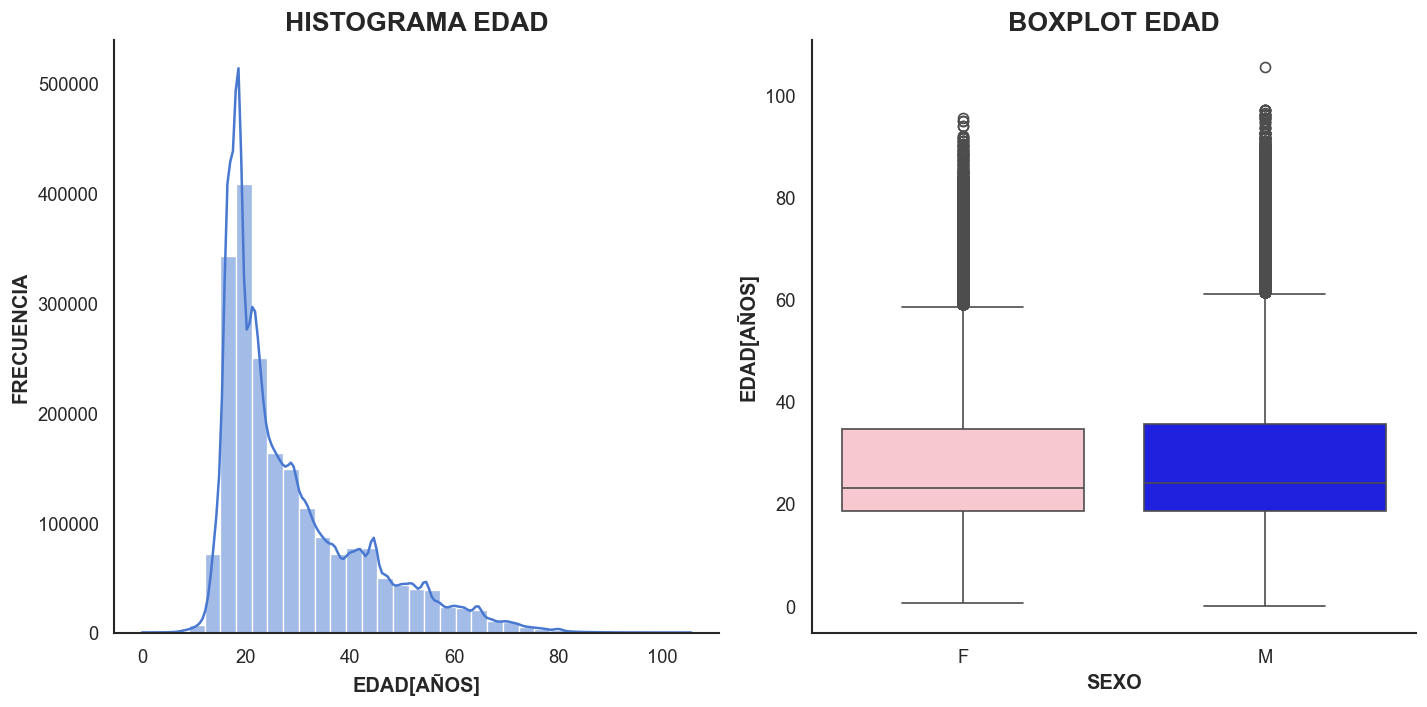

In [20]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 6))

ax[0].set_title("HISTOGRAMA EDAD")
ax[0].set_xlabel("EDAD[AÑOS]")
ax[0].set_ylabel("FRECUENCIA")


sns.histplot(
		data = clean_df,
		x = 'Age',
        binwidth = 3,
        kde = True,
        ax = ax[0]
		)

ax[1].set_title("BOXPLOT EDAD")
ax[1].set_xlabel("SEXO")
ax[1].set_ylabel("EDAD[AÑOS]")

sns.boxplot(
		data = clean_df,
		x = 'Sex',
        y = 'Age',
        palette = {
            'F': 'pink',
            'M': 'blue'
            },
        ax = ax[1]
		)

plt.tight_layout()
plt.show()

# I am aware of the warning and I know how to fix it, but I left it like this because after doing what it indicates, the labels do not match the bars and it looks better this way.

We can see that the majority of athletes are concentrated around age 20 (whereas before the average was around 30), which will make the results for this age group more statistically reliable than the rest. Even so, given the large volume of data, the analysis will remain robust across all ages. Men and women are distributed homogeneously.

**WEIGHT**

C:\Users\Lap-user\AppData\Local\Temp\ipykernel_12432\1080516391.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


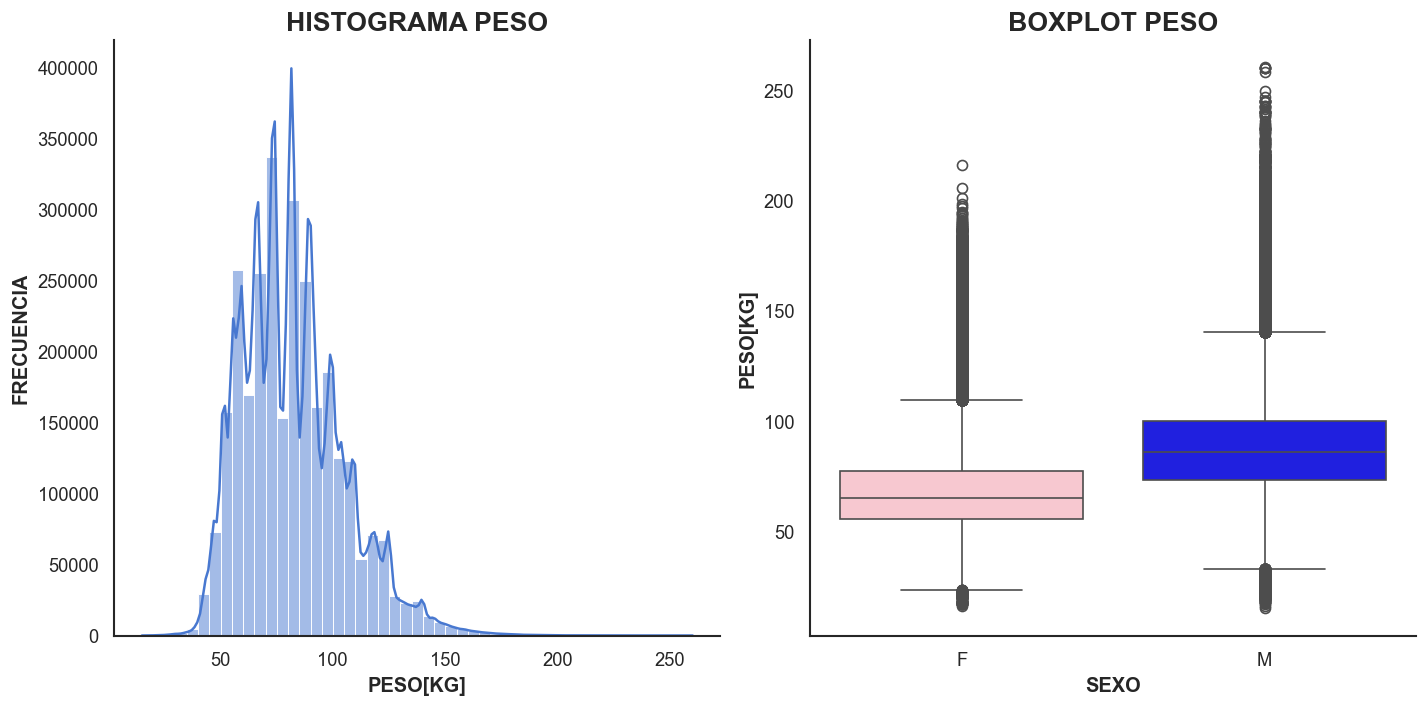

In [21]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 6))

ax[0].set_title("HISTOGRAMA PESO")
ax[0].set_xlabel("PESO[KG]")
ax[0].set_ylabel("FRECUENCIA")


sns.histplot(
		data = clean_df,
		x = 'BodyweightKg',
        binwidth = 5,
        kde = True,
        ax = ax[0]
		)

ax[1].set_title("BOXPLOT PESO")
ax[1].set_xlabel("SEXO")
ax[1].set_ylabel("PESO[KG]")

sns.boxplot(
		data = clean_df,
		x = 'Sex',
        y = 'BodyweightKg',
        palette = {
            'F': 'pink',
            'M': 'blue'
            },
        ax = ax[1]
		)

plt.tight_layout()
plt.show()

# I am aware of the warning and I know how to fix it, but I left it like this because after doing what it indicates, the labels do not match the bars and it looks better this way.

We can see that the majority of athletes are concentrated around 60-80 kg, which is exactly the average for women and men, respectively.

### 6.2. Univariate analysis of categorical variables

**EQUIPMENT**

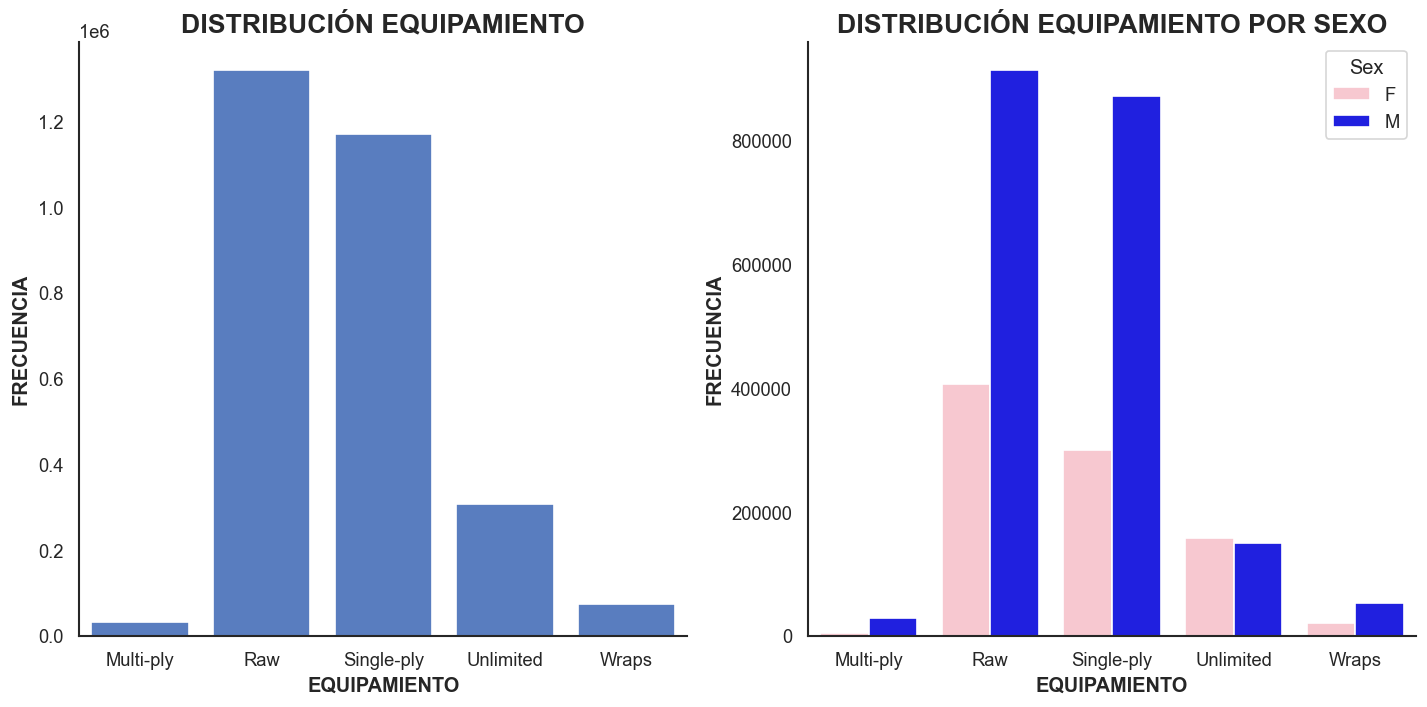

In [22]:
fig, ax = plt.subplots(nrows = 1, ncols = 2,figsize = (12, 6))

ax[0].set_title("DISTRIBUCIÓN EQUIPAMIENTO")
ax[0].set_xlabel("EQUIPAMIENTO")
ax[0].set_ylabel("FRECUENCIA")


sns.countplot(
		data = clean_df,
		x = 'Equipment',
        ax = ax[0]
		)

ax[1].set_title("DISTRIBUCIÓN EQUIPAMIENTO POR SEXO")
ax[1].set_xlabel("EQUIPAMIENTO")
ax[1].set_ylabel("FRECUENCIA")

sns.countplot(
		data = clean_df,
		x = 'Equipment',
        hue = 'Sex',
        palette = {
            'F': 'pink',
            'M': 'blue'
            },
        ax = ax[1]
		)

plt.tight_layout()
plt.show()

The vast majority of lifts are RAW or SINGLE-PLY, with a massive lead over the other categories, which could complicate analysis by equipment type. We can also notice that there are significantly more men than women (something we already saw in the category analysis).

**EVENT**

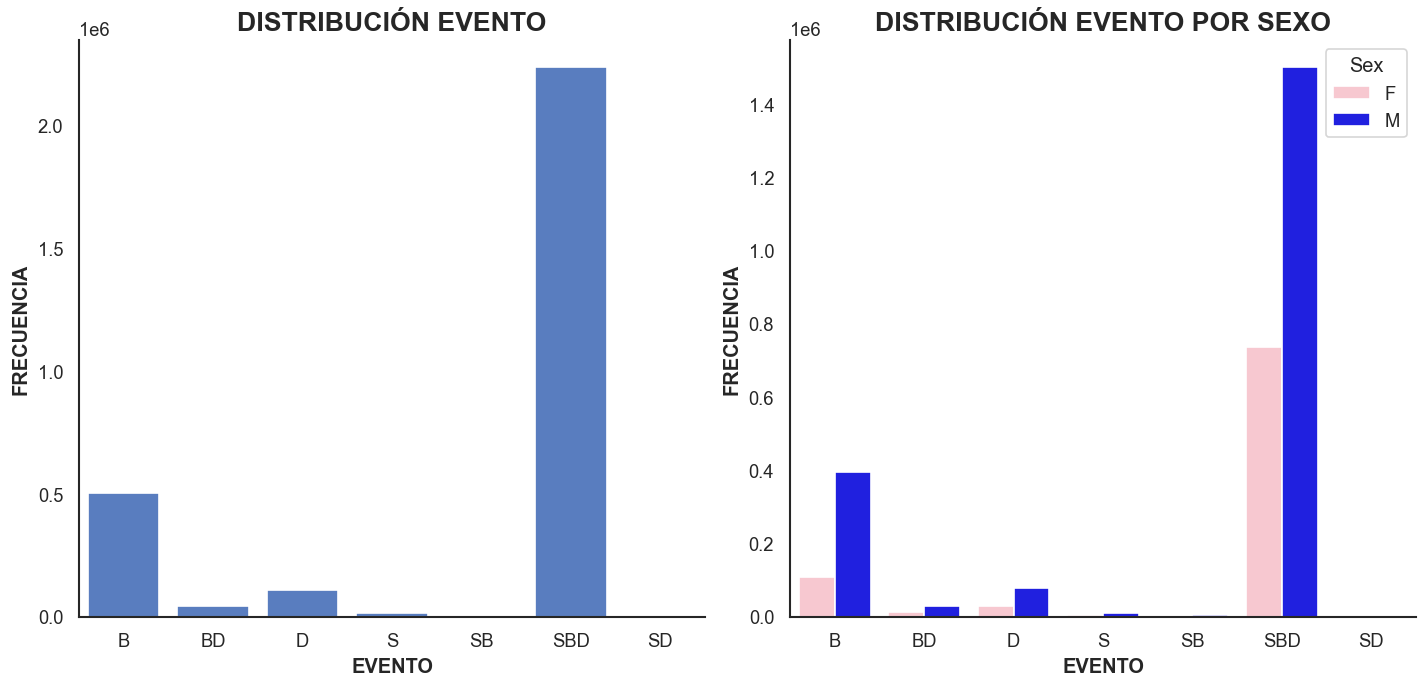

In [23]:
fig, ax = plt.subplots(nrows = 1, ncols = 2,figsize = (12, 6))

ax[0].set_title("DISTRIBUCIÓN EVENTO")
ax[0].set_xlabel("EVENTO")
ax[0].set_ylabel("FRECUENCIA")


sns.countplot(
		data = clean_df,
		x = 'Event',
        ax = ax[0]
		)

ax[1].set_title("DISTRIBUCIÓN EVENTO POR SEXO")
ax[1].set_xlabel("EVENTO")
ax[1].set_ylabel("FRECUENCIA")

sns.countplot(
		data = clean_df,
		x = 'Event',
        hue = 'Sex',
        palette = {
            'F': 'pink',
            'M': 'blue'
            },
        ax = ax[1]
		)

plt.tight_layout()
plt.show()

As we can see, the vast majority of athletes participated in FULL POWERLIFTING events (all 3 disciplines), with a huge gap over the others, which could complicate analysis for this category.

## 7. Analysis ~ Answering the Questions

### 7.1. Question 1

**At what age do athletes reach their peak performance? Does it differ between men and women?**

To answer this question, I am going to use the `Dots` metric. This metric is calculated using a polynomial formula that, among other things, standardizes the weight lifted by the athlete's body weight, making it the best way to measure performance. It is even ideal for comparing men and women, since women typically tend to weigh less and have less absolute strength, factors that are already accounted for in the `Dots` calculation.

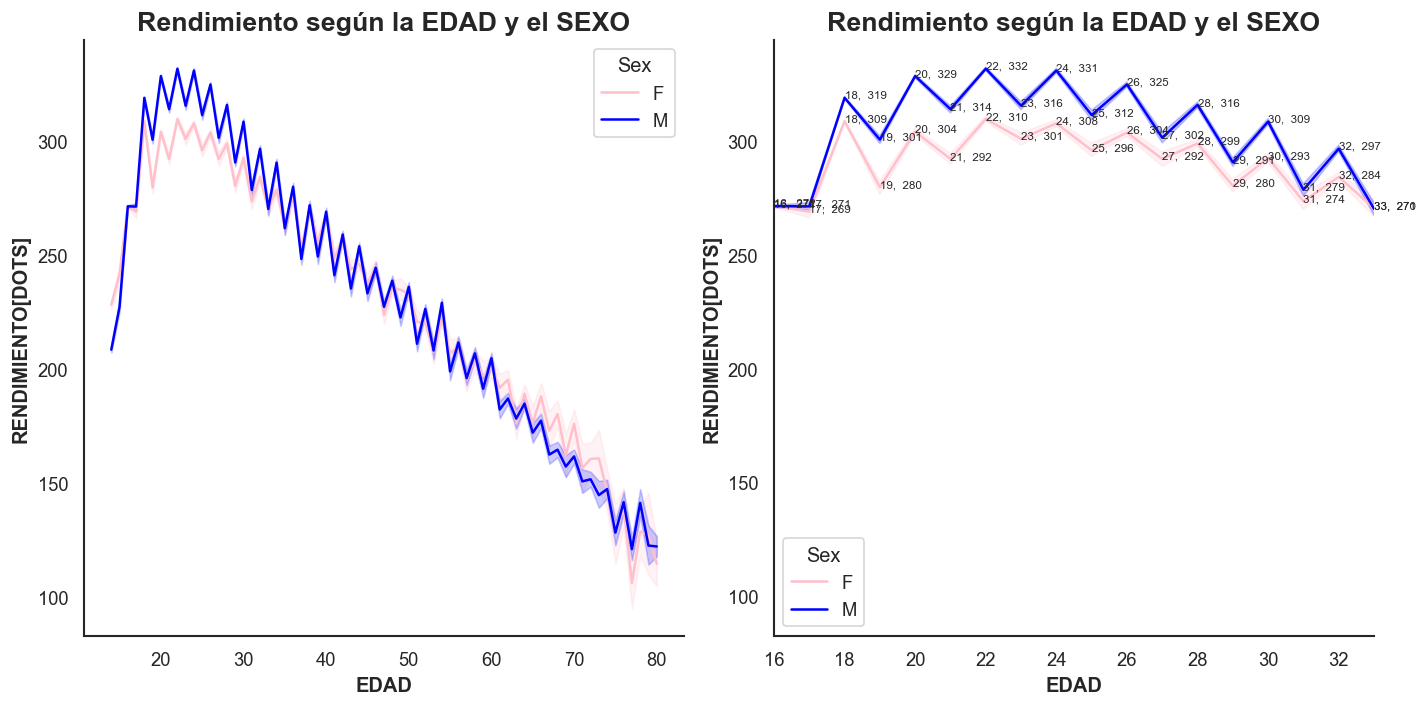

The peak performance for men is reached at 22.0 years old.
The peak performance for women is reached at 22.0 years old.


In [24]:
# PRE-CLEANING
q1_df = clean_df.dropna(subset = ['Age', 'Dots'])

# LOGIC FILTER [dataset has ages like 0.5 o 115 that are ilogic]
q1_df = q1_df[(q1_df['Age'] >= 14) & (q1_df['Age'] <= 80)]

# Plot
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 6))

ax[0].set_title("Rendimiento según la EDAD y el SEXO")
ax[0].set_xlabel("EDAD")
ax[0].set_ylabel("RENDIMIENTO[DOTS]")

sns.lineplot(
		data = q1_df,
		x = q1_df['Age'].round(),
		y = 'Dots',
        hue = 'Sex',
        palette = {
            'F': 'pink',
            'M': 'blue'
            },
        ax = ax[0]
		)

# Zoom with tags
ax[1].set_title("Rendimiento según la EDAD y el SEXO")
ax[1].set_xlabel("EDAD")
ax[1].set_ylabel("RENDIMIENTO[DOTS]")
ax[1].set_xlim(16, 33)

sns.lineplot(
		data = q1_df,
		x = q1_df['Age'].round(),
		y = 'Dots',
        hue = 'Sex',
        palette = {
            'F': 'pink',
            'M': 'blue'
            },
        ax = ax[1]
		)

# Tags
for line in ax[1].lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        ax[1].annotate(f'{x:.0f}, {y: .0f}', (x, y), fontsize = 7)

plt.tight_layout()
plt.show()

# Exacto numeric output
q1_df_sol = q1_df.groupby([q1_df['Age'].round(), 'Sex'])['Dots'].mean().reset_index()

max_m = q1_df_sol[q1_df_sol['Sex'] == 'M']['Dots'].idxmax()
max_f = q1_df_sol[q1_df_sol['Sex'] == 'F']['Dots'].idxmax()

# I use LOC instead of ILOC because IDXMAX returns LABELS, not IDX
print(f"The peak performance for men is reached at {q1_df_sol['Age'].loc[max_m]} years old.")
print(f"The peak performance for women is reached at {q1_df_sol['Age'].loc[max_f]} years old.")

**Answer**

Both visually in the graph and through calculation, we can see that the peak is reached at 22 years old. From age 14 to 18 there is accelerated progress, which slows down until reaching 22. After this point, there is a progressive and increasingly accelerated decline.

**Recommendation**

It is advisable to plan the athlete's sporting career to make the peak of physical preparation coincide with age 22, overlapping with their biological prime and thus maximizing the chances of winning a competition.

**Clarification**

The zig-zag pattern occurs because some ages do not have as many data points, making extreme values more noticeable. After the first plot, I decided to zoom in on the critical area to clearly observe the peak.

### 7.2. Question 2

**How do athletes progress within a competition? Do they increase weight between attempts 1 → 2 → 3 or do they tend to repeat/drop? By how much?**

To answer this question, I am going to use an ANOVA + Post-Hoc + Effect Size approach. Given such a large sample size, the p-value will be ~ 0, so the key here is not so much whether differences exist, but how large those differences actually are. Afterwards, I will plot a BOX-PLOT to visualize these differences.

I am removing all records where the 3 lifts are not complete because, for the ANOVA, I need to maintain the correlation between L1, L2, and L3 for each athlete.

**LIMPIEZA**

In [25]:
# PRE-CLEANING
bench_df = clean_df.dropna(subset = ['Bench1Kg', 'Bench2Kg', 'Bench3Kg'])
squat_df = clean_df.dropna(subset = ['Squat1Kg', 'Squat2Kg', 'Squat3Kg'])
deadlift_df = clean_df.dropna(subset = ['Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg'])

# UNIQUE IDX TO ENSURE PROPPER ANOVA ANALYSIS
bench_df['Idx'] = range(len(bench_df))
squat_df['Idx'] = range(len(squat_df))
deadlift_df['Idx'] = range(len(deadlift_df))

# WIDE -> LONG
bench_df = bench_df.melt(
    id_vars = ['Name', 'Sex', 'Idx'],
    value_vars = ['Bench1Kg', 'Bench2Kg', 'Bench3Kg'],
    var_name = 'Intento',
    value_name = 'Peso'
    )

squat_df = squat_df.melt(
    id_vars = ['Name', 'Sex', 'Idx'],
    value_vars = ['Squat1Kg', 'Squat2Kg', 'Squat3Kg'],
    var_name = 'Intento',
    value_name = 'Peso'
    )

deadlift_df = deadlift_df.melt(
    id_vars = ['Name', 'Sex', 'Idx'],
    value_vars = ['Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg'],
    var_name = 'Intento',
    value_name = 'Peso'
    )

**ANOVA**

In [26]:
bench_AN = pg.rm_anova(
    data = bench_df,
    dv = 'Peso',
    within = 'Intento',
    subject = 'Idx',
    effsize = 'n2'
    )

squat_AN = pg.rm_anova(
    data = squat_df,
    dv = 'Peso',
    within = 'Intento',
    subject = 'Idx',
    effsize = 'n2'
    )

deadlift_AN = pg.rm_anova(
    data = deadlift_df,
    dv = 'Peso',
    within = 'Intento',
    subject = 'Idx',
    effsize = 'n2'
    )

display(bench_AN, squat_AN, deadlift_AN)

,Source,ddof1,ddof2,F,p_unc,p_GG_corr,n2,eps,sphericity,W_spher,p_spher
0,Intento,2,874298,1771683.60,0.00,0.00,0.01,0.61,False,0.36,0.00


,Source,ddof1,ddof2,F,p_unc,p_GG_corr,n2,eps,sphericity,W_spher,p_spher
0,Intento,2,890832,2390226.40,0.00,0.00,0.02,0.61,False,0.37,0.00


,Source,ddof1,ddof2,F,p_unc,p_GG_corr,n2,eps,sphericity,W_spher,p_spher
0,Intento,2,1020412,2589670.95,0.00,0.00,0.02,0.61,False,0.37,0.00


**POST-HOC: BONFERRONI**

In [27]:
bench_PH = pg.pairwise_tests(
    data = bench_df,
    dv = 'Peso',
    within = 'Intento',
    subject = 'Idx',
    alpha = 0.05,
    alternative = 'two-sided',
    padjust = 'bonf',
    effsize = 'cohen',
    return_desc = True
    )

squat_PH = pg.pairwise_tests(
    data = squat_df,
    dv = 'Peso',
    within = 'Intento',
    subject = 'Idx',
    alpha = 0.05,
    alternative = 'two-sided',
    padjust = 'bonf',
    effsize = 'cohen',
    return_desc = True
    )

deadlift_PH = pg.pairwise_tests(
    data = deadlift_df,
    dv = 'Peso',
    within = 'Intento',
    subject = 'Idx',
    alpha = 0.05,
    alternative = 'two-sided',
    padjust = 'bonf',
    effsize = 'cohen',
    return_desc = True
    )

display(bench_PH, squat_PH, deadlift_PH)

,Contrast,A,B,mean_A,std_A,mean_B,std_B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,cohen
0,Intento,Bench1Kg,Bench2Kg,106.82,44.70,113.59,46.23,True,True,-1193.02,437149.00,two-sided,0.00,0.00,bonf,inf,-0.15
1,Intento,Bench1Kg,Bench3Kg,106.82,44.70,118.50,47.24,True,True,-1411.22,437149.00,two-sided,0.00,0.00,bonf,inf,-0.25
2,Intento,Bench2Kg,Bench3Kg,113.59,46.23,118.50,47.24,True,True,-1236.40,437149.00,two-sided,0.00,0.00,bonf,inf,-0.10


,Contrast,A,B,mean_A,std_A,mean_B,std_B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,cohen
0,Intento,Squat1Kg,Squat2Kg,156.93,56.98,167.20,59.24,True,True,-1419.42,445416.00,two-sided,0.00,0.00,bonf,inf,-0.18
1,Intento,Squat1Kg,Squat3Kg,156.93,56.98,175.08,60.58,True,True,-1634.75,445416.00,two-sided,0.00,0.00,bonf,inf,-0.31
2,Intento,Squat2Kg,Squat3Kg,167.20,59.24,175.08,60.58,True,True,-1386.37,445416.00,two-sided,0.00,0.00,bonf,inf,-0.13


,Contrast,A,B,mean_A,std_A,mean_B,std_B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,cohen
0,Intento,Deadlift1Kg,Deadlift2Kg,167.87,54.97,179.72,57.24,True,True,-1477.27,510206.00,two-sided,0.00,0.00,bonf,inf,-0.21
1,Intento,Deadlift1Kg,Deadlift3Kg,167.87,54.97,188.82,58.65,True,True,-1702.81,510206.00,two-sided,0.00,0.00,bonf,inf,-0.37
2,Intento,Deadlift2Kg,Deadlift3Kg,179.72,57.24,188.82,58.65,True,True,-1439.40,510206.00,two-sided,0.00,0.00,bonf,inf,-0.16


**BOXPLOT**

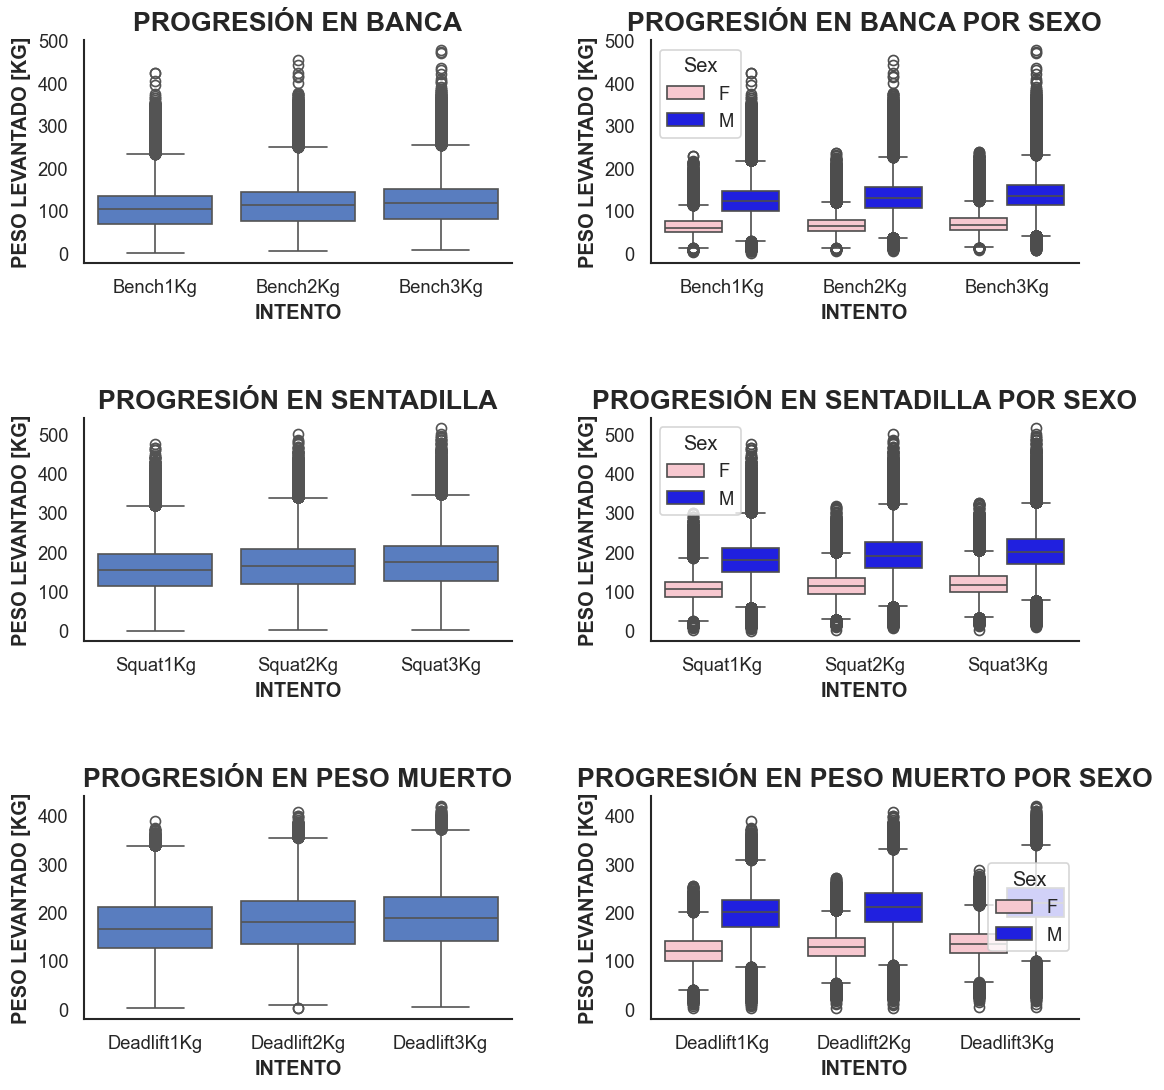

In [28]:
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (10, 10))

# BENCH
ax[0][0].set_title("PROGRESIÓN EN BANCA")
ax[0][0].set_xlabel("INTENTO")
ax[0][0].set_ylabel("PESO LEVANTADO [KG]")

sns.boxplot(
		data = bench_df,
		x = 'Intento',
		y = 'Peso',
        ax = ax[0][0]
		)

# BENCH BY SEX
ax[0][1].set_title("PROGRESIÓN EN BANCA POR SEXO")
ax[0][1].set_xlabel("INTENTO")
ax[0][1].set_ylabel("PESO LEVANTADO [KG]")

sns.boxplot(
		data = bench_df,
		x = 'Intento',
		y = 'Peso',
        hue = 'Sex',
        palette = {
            'F': 'pink',
            'M': 'blue'
            },
        ax = ax[0][1]
		)

# SQUAT
ax[1][0].set_title("PROGRESIÓN EN SENTADILLA")
ax[1][0].set_xlabel("INTENTO")
ax[1][0].set_ylabel("PESO LEVANTADO [KG]")

sns.boxplot(
		data = squat_df,
		x = 'Intento',
		y = 'Peso',
        ax = ax[1][0]
		)

# SQUAT BY SEX
ax[1][1].set_title("PROGRESIÓN EN SENTADILLA POR SEXO")
ax[1][1].set_xlabel("INTENTO")
ax[1][1].set_ylabel("PESO LEVANTADO [KG]")

sns.boxplot(
		data = squat_df,
		x = 'Intento',
		y = 'Peso',
        hue = 'Sex',
        palette = {
            'F': 'pink',
            'M': 'blue'
            },
        ax = ax[1][1]
		)

# DEADLIFT
ax[2][0].set_title("PROGRESIÓN EN PESO MUERTO")
ax[2][0].set_xlabel("INTENTO")
ax[2][0].set_ylabel("PESO LEVANTADO [KG]")

sns.boxplot(
		data = deadlift_df,
		x = 'Intento',
		y = 'Peso',
        ax = ax[2][0]
		)

# DEADLIFT BY SEX
ax[2][1].set_title("PROGRESIÓN EN PESO MUERTO POR SEXO")
ax[2][1].set_xlabel("INTENTO")
ax[2][1].set_ylabel("PESO LEVANTADO [KG]")

sns.boxplot(
		data = deadlift_df,
		x = 'Intento',
		y = 'Peso',
        hue = 'Sex',
        palette = {
            'F': 'pink',
            'M': 'blue'
            },
        ax = ax[2][1]
		)

plt.tight_layout(pad = 4)
plt.show()

**Answer**

We start with the ANOVA, which as expected, showed significant differences across all groups given the sheer size of the dataset. Moving on to the post-hoc analysis, we can extract all the detailed insights alongside the charts. Focusing first on the post-hoc results (and ignoring row 1, which represents the jump from lift 1 to lift 3), we can see that although the effect size [Cohen's d] is classified as "small," translating it into actual kilos reveals considerable differences for all three exercises and across all attempts.

This is exactly what the charts illustrate. Looking first at the ones on the left, we can see that they all follow a staircase pattern, confirming that athletes increase the weight from one attempt to the next. For instance, if we look at the group means in the post-hoc analysis, there is a 5-10 kg increase in all exercises, both when moving from the first to the second attempt, and from the second to the third. As I mentioned, this might seem like a small amount, but even an extra 2 kg on the bar is massive given the high level of competition and the heavy weights involved.

Additionally, I decided to generate charts broken down by sex to visually assess whether men and women progress equally after each lift. The answer is yes. Although men handle heavier weights, the progression pattern between attempts is practically identical.

**Clarification**

Despite not formally checking the ANOVA assumptions, the analysis remains completely valid. According to the Central Limit Theorem, with a dataset of over 1 million records, the distribution of the sample means will be perfectly normal, just as the ANOVA p-value will inevitably be ~ 0.

### 7.3. Question 3

**In which lift (squat, bench, deadlift) do the most misses occur on the 3rd attempt?**

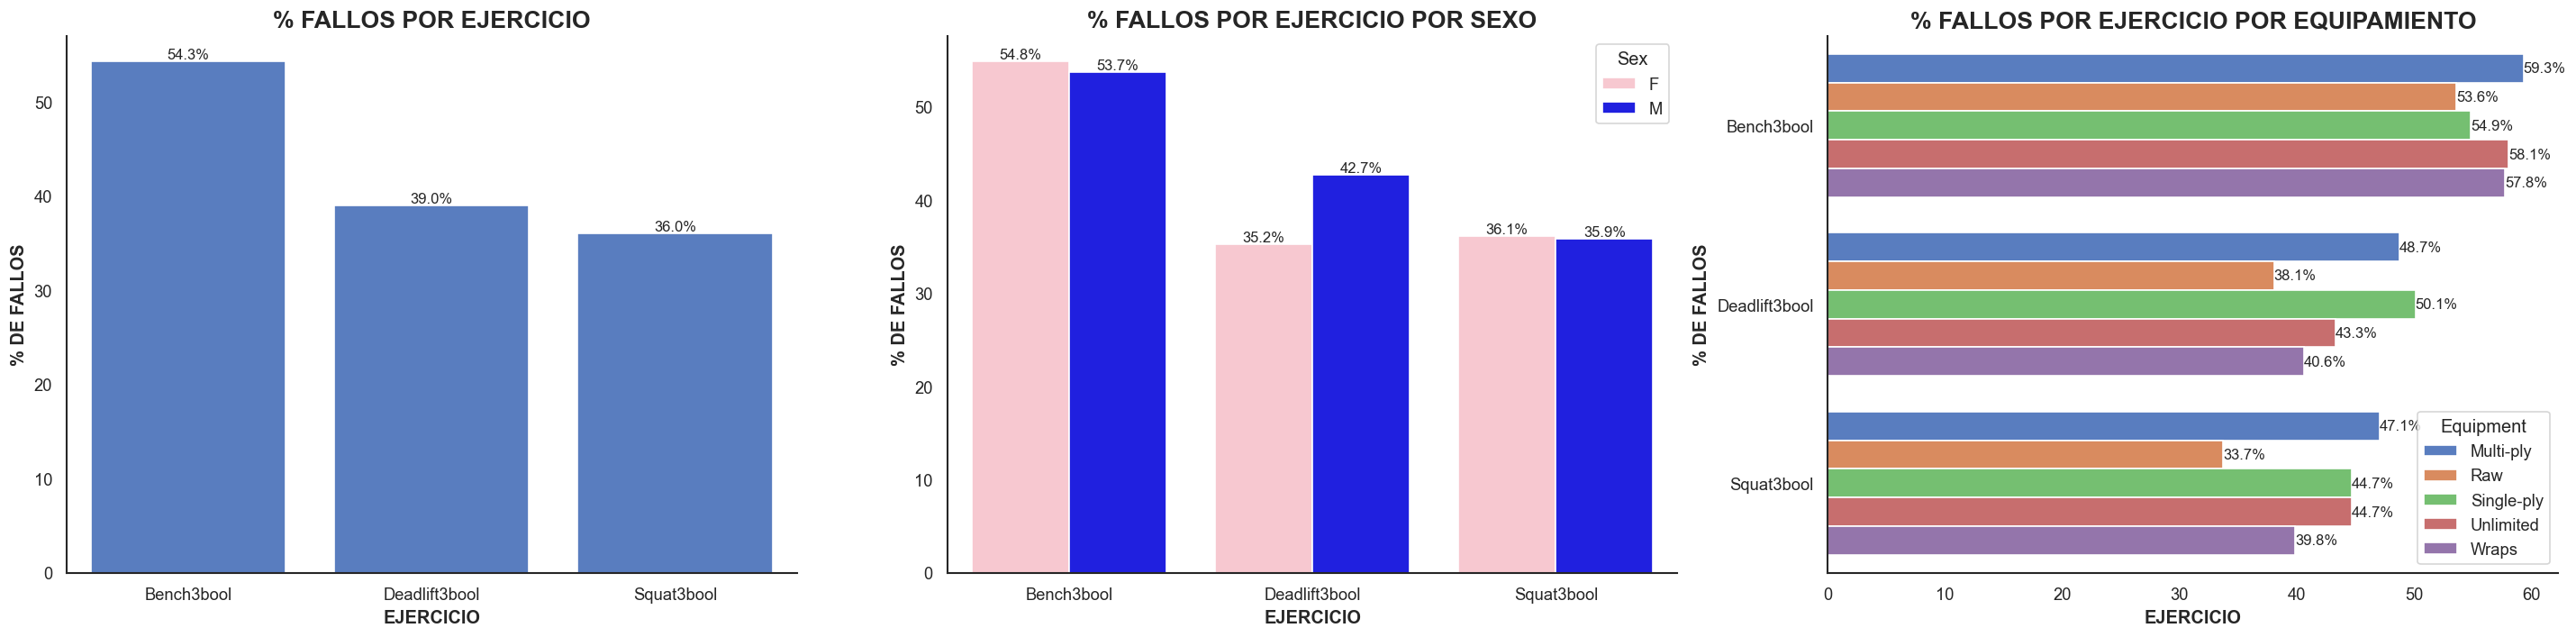

In [29]:
# WIDE -> LONG
q3_df = clean_df.melt(
    id_vars = ['Name', 'Sex', 'Equipment'],
    value_vars = ['Bench3bool', 'Squat3bool', 'Deadlift3bool'],
    var_name = 'Levantamiento',
    value_name = 'Éxito'
)

# CLEANING EMPTY LIFTS (NO ATHLETES)
q3_df = q3_df.dropna(subset = ['Éxito'])

# NORMALIZED FAILRATE WITH TOTAL LIFS FOR SEX AND EQUIPMENT
fallo_sexo_df = q3_df.groupby(['Levantamiento', 'Sex'])['Éxito'].apply(lambda x: (x == False).mean() * 100).reset_index(name = 'Fallos(%)')
fallo_equip_df = q3_df.groupby(['Levantamiento', 'Equipment'])['Éxito'].apply(lambda x: (x == False).mean() * 100).reset_index(name = 'Fallos(%)')

# PLOT
fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (24, 6))

ax[0].set_title("% FALLOS POR EJERCICIO")
ax[0].set_xlabel("EJERCICIO")
ax[0].set_ylabel("% DE FALLOS")

sns.barplot(
    data = fallo_sexo_df,
    x = 'Levantamiento',
    y = 'Fallos(%)',
    orient = 'v',
    errorbar = None,
    ax = ax[0]    
)

# TAGS
ax[0].bar_label(ax[0].containers[0], fmt = '%.1f%%')

# PLOT BY SEX
ax[1].set_title("% FALLOS POR EJERCICIO POR SEXO")
ax[1].set_xlabel("EJERCICIO")
ax[1].set_ylabel("% DE FALLOS")

sns.barplot(
    data = fallo_sexo_df,
    x = 'Levantamiento',
    y = 'Fallos(%)',
    hue = 'Sex',
    orient = 'v',
    palette = {
            'F': 'pink',
            'M': 'blue'
            },
    errorbar = None,
    ax = ax[1]
)

# TAGS
for container in ax[1].containers:
    ax[1].bar_label(container, fmt='%.1f%%')

# LEGEND
sns.move_legend(ax[1], "upper right")

# PLOT BY EQUIPMENT
ax[2].set_title("% FALLOS POR EJERCICIO POR EQUIPAMIENTO")
ax[2].set_xlabel("EJERCICIO")
ax[2].set_ylabel("% DE FALLOS")

sns.barplot(
    data = fallo_equip_df,
    x = 'Fallos(%)',
    y = 'Levantamiento',
    hue = 'Equipment',
    orient = 'h',
    errorbar = None,
    ax = ax[2]
)

# TAGS
for container in ax[2].containers:
    ax[2].bar_label(container, fmt='%.1f%%')

# LEGEND
sns.move_legend(ax[2], "lower right")

plt.tight_layout()
plt.show()

**Answer**

Clearly, the exercise with the highest failure rate on the third attempt is the bench press, where over half of the attempts end in a miss, regardless of sex. For the remaining exercises, it depends on sex. Men miss significantly more in the deadlift than in the squat, whereas women miss practically equally in both exercises. The key takeaway is that for all three lifts, and especially for the bench press, the third attempt carries a relatively high probability of failure.

Interestingly, looking at the failure percentage by equipment type, `RAW` is consistently the "equipment" category with the lowest percentage of misses. However, given that `RAW` accounts for approximately 2.5 million lifts, while the next largest is `SINGLE-PLY` with around 60,000, and `UNLIMITED` is the smallest with roughly 3,000, these results must be interpreted with caution.

**Recommendation**

This question completely changes the narrative from the second question. Knowing that most athletes follow an ascending strategy—making their final attempt the heaviest, the one most likely to fail, and the one that determines who wins—the winning strategy might actually be to secure a very heavy second attempt. Let's say that by following this strategy, your second lift puts you in the lead. Now, the rest of the athletes have to take risks to beat you, which will increase their chances of failing even further due to the pressure. Furthermore, keeping this in mind, it might be a better idea to approach the third attempt with less risk to ensure you successfully lock it locked in, especially in the bench press.

### 7.4. Question 4

**Do athletes who compete in multiple full lifting events perform better or worse than those who specialize in a single type of lift?**

We cannot use `Dots` to compare performance based on the lifts performed because Dots is calculated using the `TotalKg` lifted. Consequently, someone participating in a full competition will always have a higher `Dots` score than someone participating in a single-lift event. To address this, I am going to create a new "pseudo-Dots" metric for each exercise by dividing the best of the three lifts by the athlete's body weight. I will then verify that my metric correlates properly with `DOTS` and take the failure percentage into account to compare overall performance.

**PSEUDO_DOTS**

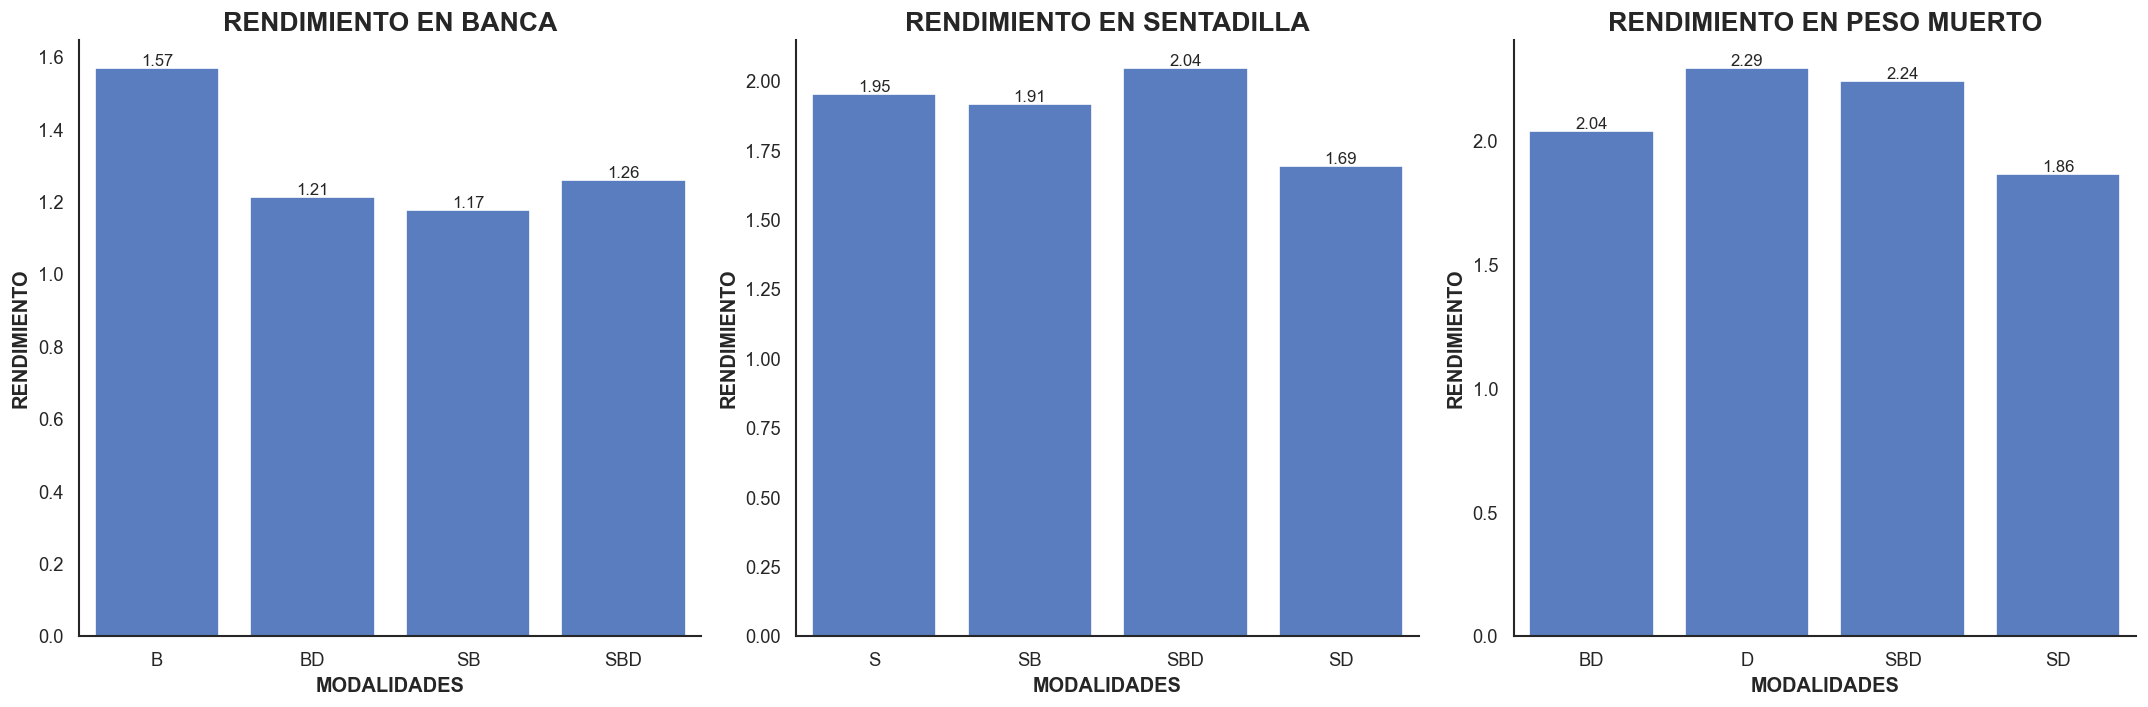

In [30]:
# PRE-CLEANING
q4a_df = clean_df.dropna(subset = ['Event'])
q4a_df['Dot_Bench'] = q4a_df['Best3BenchKg']/q4a_df['BodyweightKg']
q4a_df['Dot_Squat'] = q4a_df['Best3SquatKg']/q4a_df['BodyweightKg']
q4a_df['Dot_Deadlift'] = q4a_df['Best3DeadliftKg']/q4a_df['BodyweightKg']

# DF FOR EACH EXERCISE (+ REMOVE USELES COLS)
dot_bench_df = q4a_df[~q4a_df['Event'].isin(['D', 'S', 'SD'])].dropna(subset = ['Best3BenchKg'])
dot_bench_df['Event'] = dot_bench_df['Event'].cat.remove_unused_categories()

dot_squat_df = q4a_df[~q4a_df['Event'].isin(['D', 'B', 'BD'])].dropna(subset = ['Best3SquatKg'])
dot_squat_df['Event'] = dot_squat_df['Event'].cat.remove_unused_categories()

dot_deadlift_df = q4a_df[~q4a_df['Event'].isin(['B', 'S', 'SB'])].dropna(subset = ['Best3DeadliftKg'])
dot_deadlift_df['Event'] = dot_deadlift_df['Event'].cat.remove_unused_categories()

# PLOT BENCH
fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (18, 6))

ax[0].set_title("RENDIMIENTO EN BANCA")
ax[0].set_xlabel("MODALIDADES")
ax[0].set_ylabel("RENDIMIENTO")

sns.barplot(
    data = dot_bench_df,
    x = 'Event',
    y = 'Dot_Bench',
    orient = 'v',
    errorbar = None,
    ax = ax[0]    
)

ax[0].bar_label(ax[0].containers[0], fmt = '%.2f')

# PLOT SQUAT
ax[1].set_title("RENDIMIENTO EN SENTADILLA")
ax[1].set_xlabel("MODALIDADES")
ax[1].set_ylabel("RENDIMIENTO")

sns.barplot(
    data = dot_squat_df,
    x = 'Event',
    y = 'Dot_Squat',
    orient = 'v',
    errorbar = None,
    ax = ax[1]
)

ax[1].bar_label(ax[1].containers[0], fmt = '%.2f')

# PLOT DEADLIFT
ax[2].set_title("RENDIMIENTO EN PESO MUERTO")
ax[2].set_xlabel("MODALIDADES")
ax[2].set_ylabel("RENDIMIENTO")

sns.barplot(
    data = dot_deadlift_df,
    x = 'Event',
    y = 'Dot_Deadlift',
    orient = 'v',
    errorbar = None,
    ax = ax[2]
)

ax[2].bar_label(ax[2].containers[0], fmt = '%.2f')

plt.tight_layout()
plt.show()

**VERIFYING MY METRIC**

The idea is to verify that the simple metric I created correlates with `DOTS`. To do this, I will filter for athletes who have performed only a single lift and then generate the correlation matrix: `DOTS` vs. `DOT_LIFT`.

In [31]:
# DATAFRAME CREATION ONLY WITH THE SINGLE-LIFT ATHLETES FOR EACH EXERCISE
dot_bench_df = dot_bench_df[dot_bench_df['Event'].isin(['B'])]
dot_squat_df = dot_squat_df[dot_squat_df['Event'].isin(['S'])]
dot_deadlift_df = dot_deadlift_df[dot_deadlift_df['Event'].isin(['D'])]

# CORRELATIONS
corr_bench = dot_bench_df[['Dots', 'Dot_Bench']].dropna().corr()
corr_squat = dot_squat_df[['Dots', 'Dot_Squat']].dropna().corr()
corr_deadlift = dot_deadlift_df[['Dots', 'Dot_Deadlift']].dropna().corr()

# PLOT
display(corr_bench, corr_squat, corr_deadlift)

,Dots,Dot_Bench
Dots,1.00,0.92
Dot_Bench,0.92,1.00


,Dots,Dot_Squat
Dots,1.00,0.89
Dot_Squat,0.89,1.00


,Dots,Dot_Deadlift
Dots,1.00,0.87
Dot_Deadlift,0.87,1.00


**FAIL_RATE**

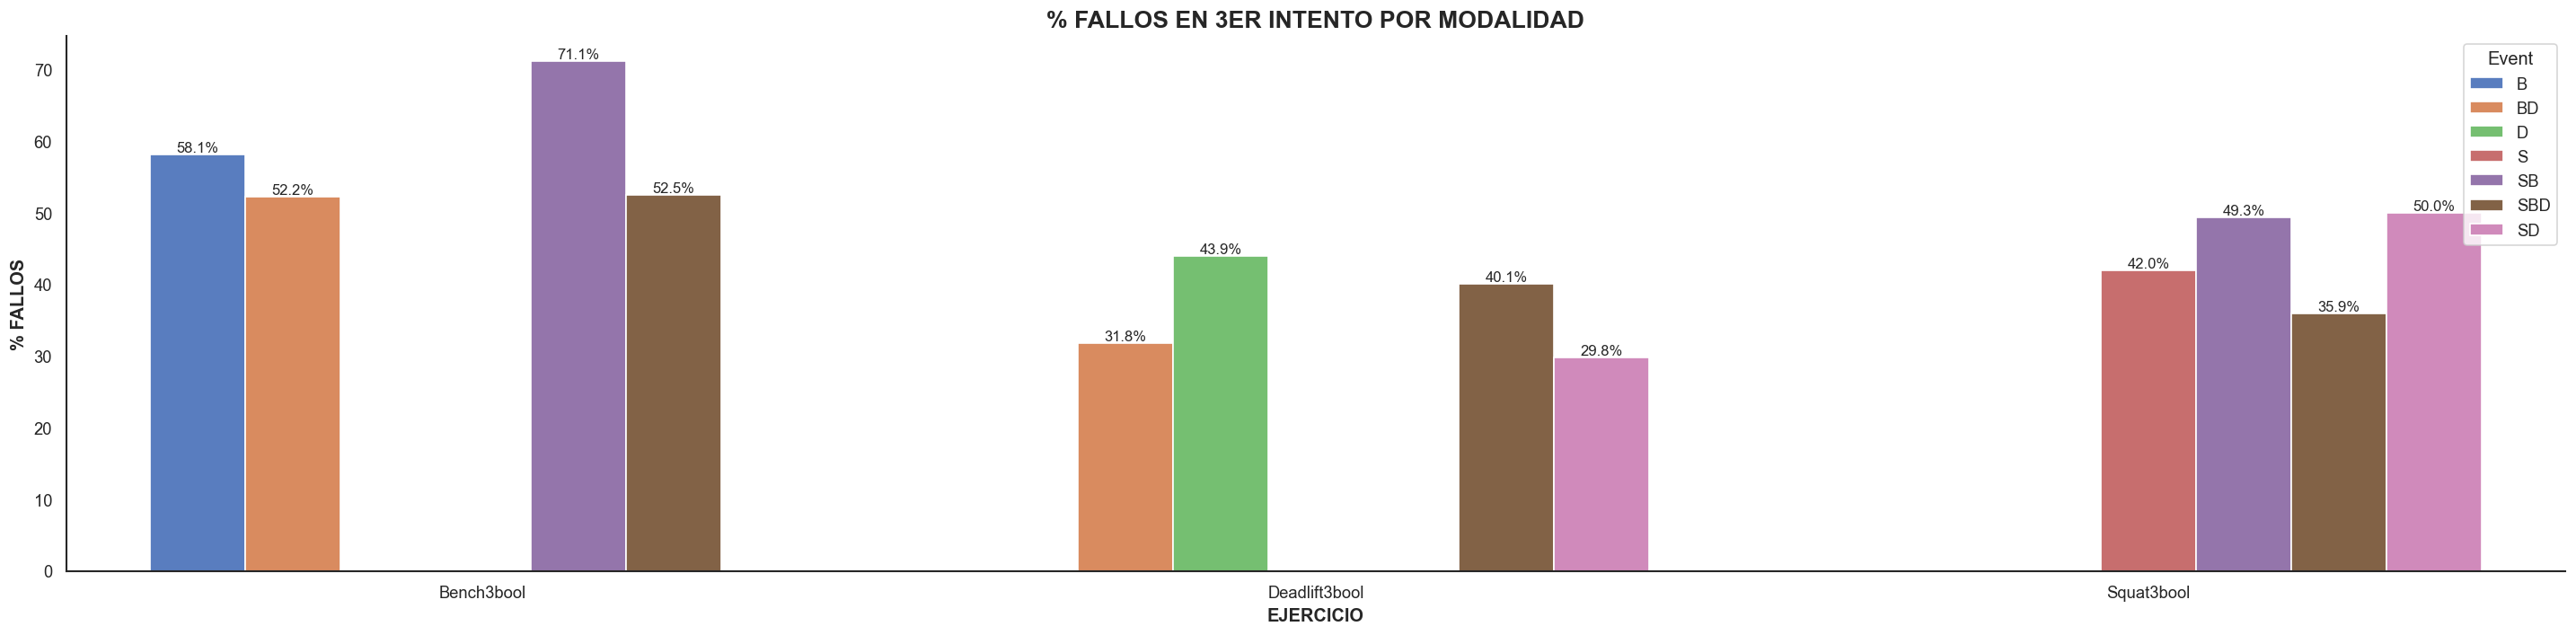

In [32]:
q4b_df = q4a_df.melt(
    id_vars = ['Name', 'Event'],
    value_vars = ['Bench3bool', 'Squat3bool', 'Deadlift3bool'],
    var_name = 'Levantamiento',
    value_name = 'Éxito'
)

q4b_df = q4b_df.groupby(['Levantamiento', 'Event'])['Éxito'].apply(lambda x: (x == False).sum() / x.dropna().count() * 100 if x.dropna().count() > 0 else np.nan).reset_index(name = 'Fallos(%)')
q4b_df = q4b_df[q4b_df['Fallos(%)'] > 0]   # REMOVING TAGS ON 0.0 (DESIGN FAIL)

# PLOT
fig, ax = plt.subplots(figsize = (24, 6))

ax.set_title("% FALLOS EN 3ER INTENTO POR MODALIDAD")
ax.set_xlabel("EJERCICIO")
ax.set_ylabel("% FALLOS")

sns.barplot(
    data = q4b_df,
    x = 'Levantamiento',
    y = 'Fallos(%)',
    orient = 'v',
    hue = 'Event',
    errorbar = None,
    ax = ax
    )

# LEGEND
sns.move_legend(ax, "upper right")

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

**Answer**

The only exercise where there appears to be a clear advantage in specializing compared to combining it with others is the bench press. For the squat and deadlift, it seems that the general strength developed in the other exercises is transferable. As for failure on the 3rd attempt [where they usually risk it all], specialists seem to fail significantly more than the rest. This might be because, by focusing on just one exercise, they push themselves much closer to their absolute limit on that specific lift.

That being said, we must take into account the data asymmetry, where the majority of records belong to SBD, with a substantial sample size for B, and a near-negligible amount for the remaining categories. Therefore, these findings should be taken with a grain of salt.

**Recommendation**

If you want to progress and stand out in the bench press, you should focus on bench exclusively. For the other two exercises, you can compete in the full-power (SBD) modality, while keeping your main focus and energy on the specific lift where you want to excel. When planning your third attempt, as previously recommended, risking too much on the 3rd lift can be detrimental, especially in the bench press.

**Clarification**

Although I "made up" this metric, the correlation matrices show that it is a very close approximation to the actual DOTS, as all correlations are above 0.85.

### 7.5. Question 5

**How successful is the 4th attempt?**

The 4th lift in powerlifting does not count toward the total score, but it allows athletes to take risks without fear to test their true strength. We are going to evaluate how often athletes succeed in breaking their limits on this 4th attempt.

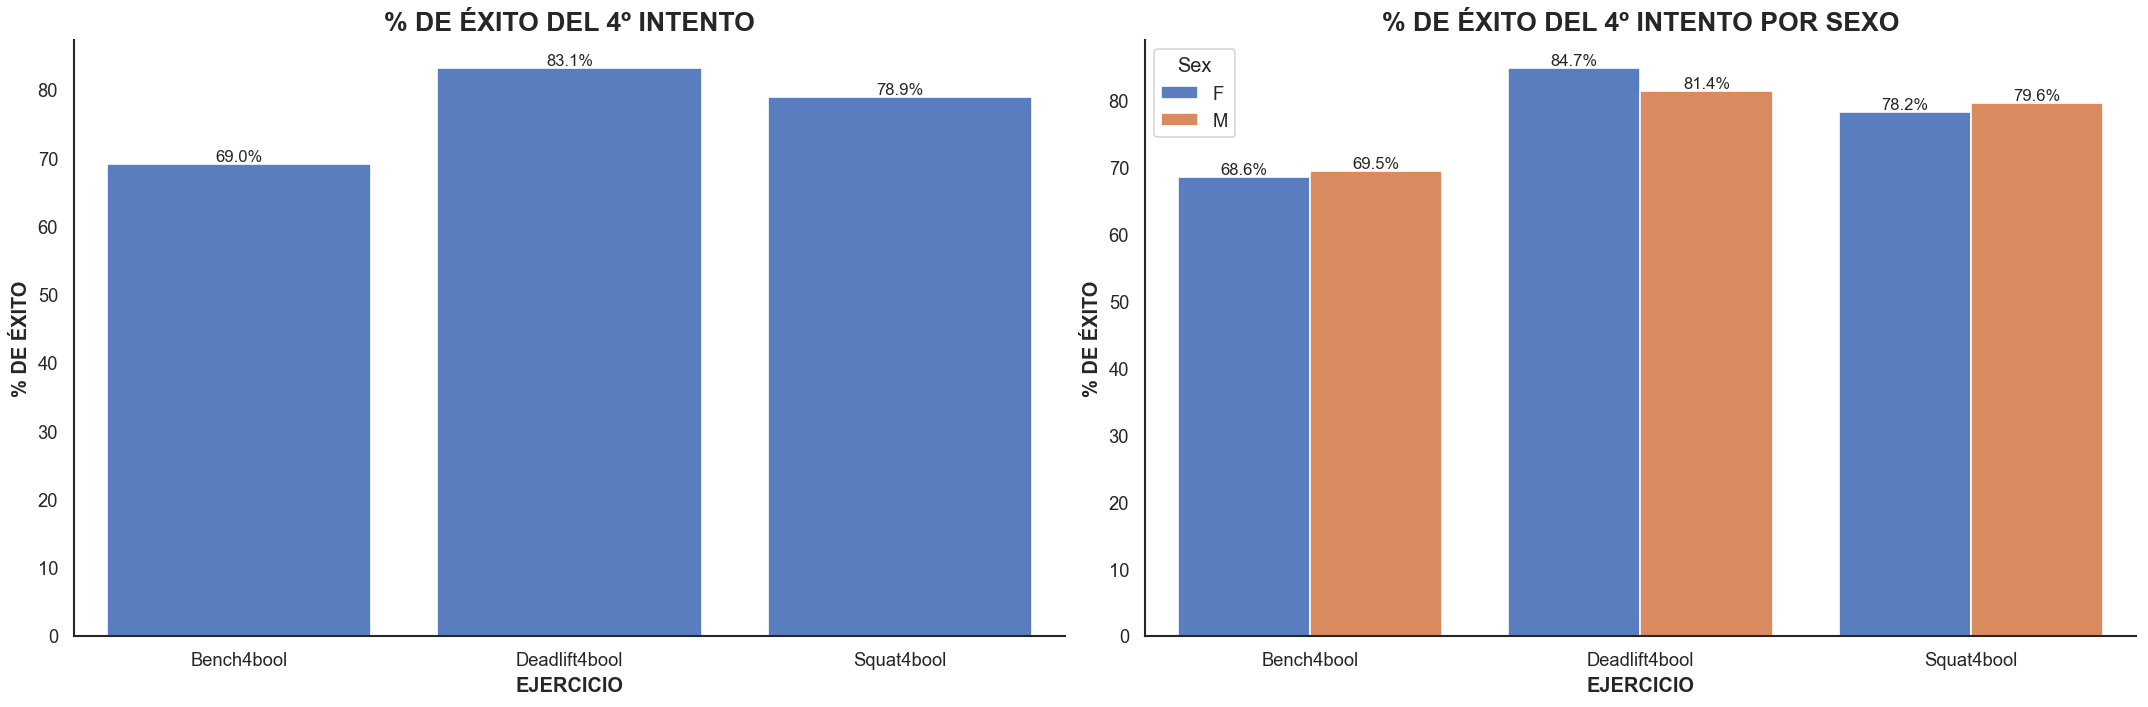

In [33]:
# WIDE -> LONG
q5_df = clean_df.melt(
    id_vars = ['Sex',],
    value_vars = ['Bench4bool', 'Squat4bool', 'Deadlift4bool'],
    var_name = 'Levantamiento',
    value_name = 'Éxito'
)

# CLEANING EMPTY LIFTS (NO ATHLETES)
q5_df = q5_df.dropna(subset = ['Éxito'])

# NORMALIZED FAILRATE WITH TOTAL LIFTS
q5_df = q5_df.groupby(['Levantamiento', 'Sex'])['Éxito'].agg(lambda x: (x == True).sum() / x.dropna().count() * 100).reset_index(name = 'Éxitos(%)')

# PLOT
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (18, 6))

ax[0].set_title("% DE ÉXITO DEL 4º INTENTO")
ax[0].set_xlabel("EJERCICIO")
ax[0].set_ylabel("% DE ÉXITO")

sns.barplot(
    data = q5_df,
    x = 'Levantamiento',
    y = 'Éxitos(%)',
    orient = 'v',
    errorbar = None,
    ax = ax[0]    
)

ax[0].bar_label(ax[0].containers[0], fmt = '%.1f%%')

# PLOT BY SEX
ax[1].set_title("% DE ÉXITO DEL 4º INTENTO POR SEXO")
ax[1].set_xlabel("EJERCICIO")
ax[1].set_ylabel("% DE ÉXITO")

sns.barplot(
    data = q5_df,
    x = 'Levantamiento',
    y = 'Éxitos(%)',
    orient = 'v',
    hue = 'Sex',
    errorbar = None,
    ax = ax[1]    
)

for container in ax[1].containers:
    ax[1].bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

**Answer**

In line with the previous findings, the bench press continues to be the exercise with the highest failure rate. Even so, the 4th attempt is highly successful across all three exercises regardless of sex, as the majority of people who attempt it usually complete it successfully. It might be worth considering a potential data bias, given that athletes who attempt a 4th lift and miss might not have it recorded, whereas successful attempts are much more likely to be documented.

**Recommendation**

You should always take a 4th attempt to test yourself and discover new limits ahead of future competitions.

## 8. Conclusions

Based on the analyzed data, we can conclude that:

- The peak performance for a powerlifting athlete arrives around age 22 and is maintained until age 24, after which it begins to decline at an increasingly accelerated pace.

- The bench press is notably different from the deadlift and the squat, as it is the only exercise where specialization shows a clear performance improvement, and it is the only one with a third-attempt failure rate higher than 50%. For the squat and deadlift, the strength developed in the other exercises seems to be transferable, and their failure rate is much lower (~30%) [A conclusion to be taken with caution given the asymmetry of the data].

- The tendency of all athletes to exceed their previous lift in the next attempt suggests that the most critical lift in a competition is the final one. At the same time, the number of failures on this last attempt is high, especially in the bench press. Combined, these two insights can help design a strategy focused on taking a big risk on the second attempt to put pressure on the rest of the competitors.

- It is recommended that all athletes take the fourth lift because, being free of pressure, it boasts a success rate of ~ 80% (pending verification that there is no reporting bias). This is incredibly important for the preparation of future competitions.

- Extra note: No differences by sex were observed in any of the studied characteristics except, obviously, for absolute weights, which disappears after normalizing by body weight.

For future analysis, it would be advisable to:

- Design a model to predict the maximum weight an athlete can lift without failing on their next attempt, thereby providing further assistance in competition planning.

- It would be interesting to incorporate biological data such as hours of sleep, diet, and recovery prior to competitions to perform a more robust analysis.

- It could be worthwhile to repeat this study while keeping only the SBD category (full powerlifting), since it appears to be the predominant one. This way, the results would be even more transferable.